In [1]:
import pandas as pd
import numpy as np
import datetime

   
# LOAD DATA
   
file_path = "india_housing_prices.csv"

try:
    df = pd.read_csv(file_path)
    print("Data loaded successfully")
except Exception as e:
    print("Error loading file:", e)
    raise

print("\nInitial Shape:", df.shape)

   
# CLEAN COLUMN NAMES
   
df.columns = df.columns.str.strip()

   
# REMOVE DUPLICATES ONLY
   
df = df.drop_duplicates().reset_index(drop=True)
print("Duplicates removed:", df.shape)

   
# SAFE TYPE CONVERSION FUNCTION
   
def safe_numeric(col):
    return pd.to_numeric(col, errors='coerce')

   
# HANDLE NUMERIC COLUMNS
   
numeric_cols = [
    'BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt',
    'Year_Built', 'Floor_No', 'Total_Floors',
    'Nearby_Schools', 'Nearby_Hospitals',
    'Public_Transport_Accessibility', 'Parking_Space'
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = safe_numeric(df[col])

        # Fill missing with median safely
        if df[col].notnull().sum() > 0:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(0)

   
# HANDLE CATEGORICAL COLUMNS
   
categorical_cols = [
    'State', 'City', 'Locality', 'Property_Type',
    'Furnished_Status', 'Security', 'Amenities',
    'Facing', 'Owner_Type', 'Availability_Status'
]

for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.lower()

        df[col] = df[col].replace(
            ['nan', 'none', '', 'null'], 'unknown'
        )

        df[col] = df[col].fillna('unknown')

   
# FIX DATA TYPES
   
int_cols = ['BHK', 'Floor_No', 'Total_Floors', 'Parking_Space']

for col in int_cols:
    if col in df.columns:
        df[col] = df[col].round().fillna(0).astype(int)

float_cols = [
    'Size_in_SqFt', 'Price_in_Lakhs',
    'Nearby_Schools', 'Nearby_Hospitals',
    'Public_Transport_Accessibility'
]

for col in float_cols:
    if col in df.columns:
        df[col] = df[col].astype(float)

   
# YEAR BUILT FIX
   
current_year = datetime.datetime.now().year

if 'Year_Built' in df.columns:
    df['Year_Built'] = df['Year_Built'].clip(lower=1900, upper=current_year)
    df['Year_Built'] = df['Year_Built'].fillna(current_year)

   
# FEATURE ENGINEERING
   

# Age of Property
if 'Year_Built' in df.columns:
    df['Age_of_Property'] = current_year - df['Year_Built']

# Safe Price per SqFt
if 'Price_in_Lakhs' in df.columns and 'Size_in_SqFt' in df.columns:
    df['Size_in_SqFt'] = df['Size_in_SqFt'].replace(0, np.nan)

    df['Price_per_SqFt'] = df['Price_in_Lakhs'] / df['Size_in_SqFt']

    # Fill safely
    if df['Price_per_SqFt'].notnull().sum() > 0:
        df['Price_per_SqFt'] = df['Price_per_SqFt'].fillna(df['Price_per_SqFt'].median())
    else:
        df['Price_per_SqFt'] = df['Price_per_SqFt'].fillna(0)

   
# STANDARDIZE TEXT VALUES
   
if 'Furnished_Status' in df.columns:
    df['Furnished_Status'] = df['Furnished_Status'].replace({
        'semi furnished': 'semi-furnished',
        'fully furnished': 'fully-furnished'
    })

if 'Property_Type' in df.columns:
    df['Property_Type'] = df['Property_Type'].str.replace('_', ' ')

   
# CREATE TARGET VARIABLE (SAFE)
   
if 'Price_per_SqFt' in df.columns:
    median_price = df['Price_per_SqFt'].median()
    df['Good_Investment'] = (df['Price_per_SqFt'] > median_price).astype(int)

   
# FINAL CHECK
   
print("\nFinal Shape:", df.shape)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

   
# SAVE CLEANED DATA
   
output_file = "cleaned_real_estate_data.csv"

try:
    df.to_csv(output_file, index=False)
    print(f"\nCleaned dataset saved as: {output_file}")
except Exception as e:
    print("Error saving file:", e)

Data loaded successfully

Initial Shape: (250000, 23)
Duplicates removed: (250000, 23)

Final Shape: (250000, 24)

Missing Values After Cleaning:
ID                                0
State                             0
City                              0
Locality                          0
Property_Type                     0
BHK                               0
Size_in_SqFt                      0
Price_in_Lakhs                    0
Price_per_SqFt                    0
Year_Built                        0
Furnished_Status                  0
Floor_No                          0
Total_Floors                      0
Age_of_Property                   0
Nearby_Schools                    0
Nearby_Hospitals                  0
Public_Transport_Accessibility    0
Parking_Space                     0
Security                          0
Amenities                         0
Facing                            0
Owner_Type                        0
Availability_Status               0
Good_Investment           

Data Loaded: (250000, 24)


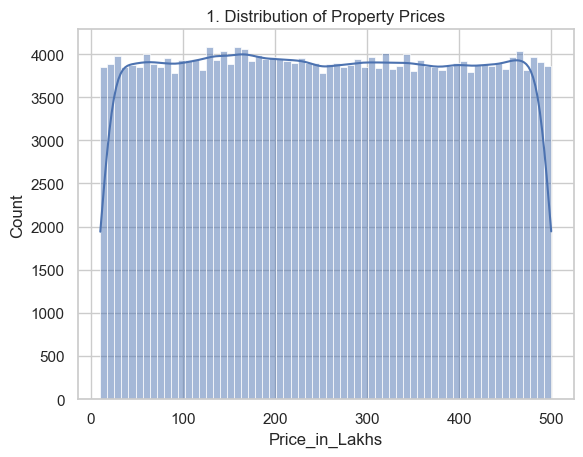

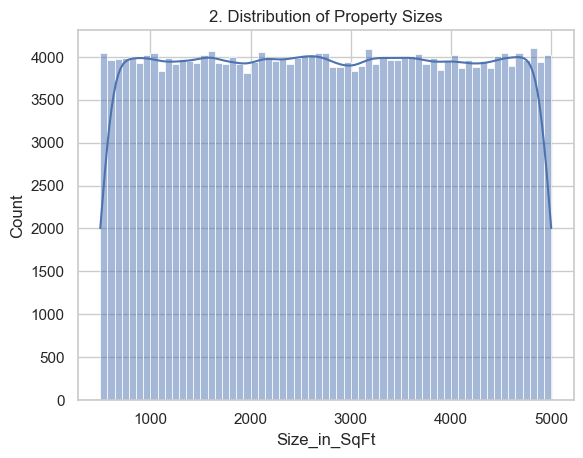

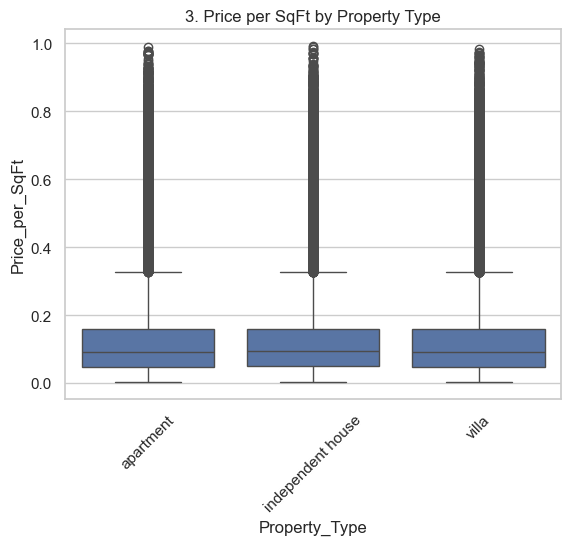

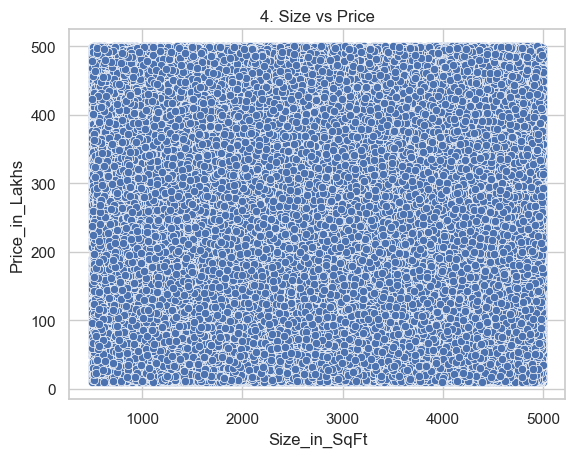

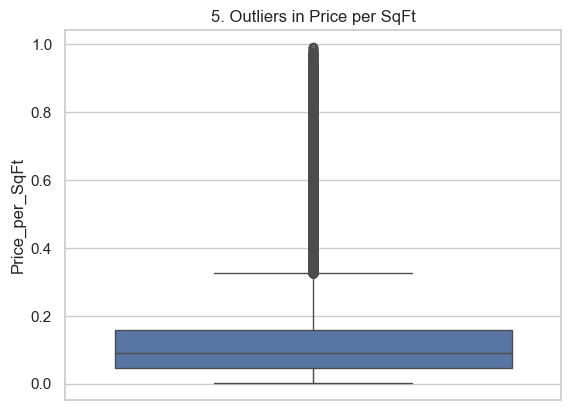


6. Avg Price per SqFt by State:
 State
karnataka         0.132522
andhra pradesh    0.132016
uttar pradesh     0.131425
tamil nadu        0.131324
telangana         0.130931
gujarat           0.130911
assam             0.130840
maharashtra       0.130701
madhya pradesh    0.130690
haryana           0.130687
west bengal       0.130605
bihar             0.130506
odisha            0.130329
chhattisgarh      0.130271
uttarakhand       0.130271
kerala            0.129822
jharkhand         0.129755
delhi             0.129413
rajasthan         0.129322
punjab            0.129315
Name: Price_per_SqFt, dtype: float64

7. Avg Property Price by City:
 City
bangalore         258.456639
surat             258.080467
kochi             257.415221
gaya              257.053391
mangalore         256.920925
dehradun          256.890115
mysore            256.848172
chennai           256.830172
hyderabad         256.594051
coimbatore        256.504745
bhopal            256.498896
pune              256.4956

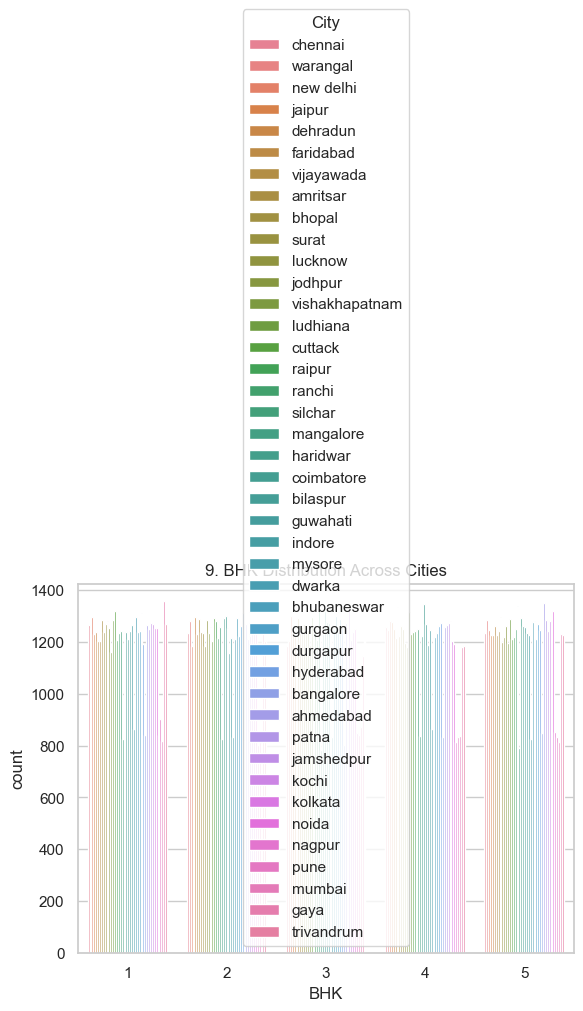


10. Top 5 Expensive Localities:
 Locality
locality_395    275.425987
locality_366    273.411996
locality_497    269.995540
locality_360    269.806792
locality_203    269.033716
Name: Price_in_Lakhs, dtype: float64


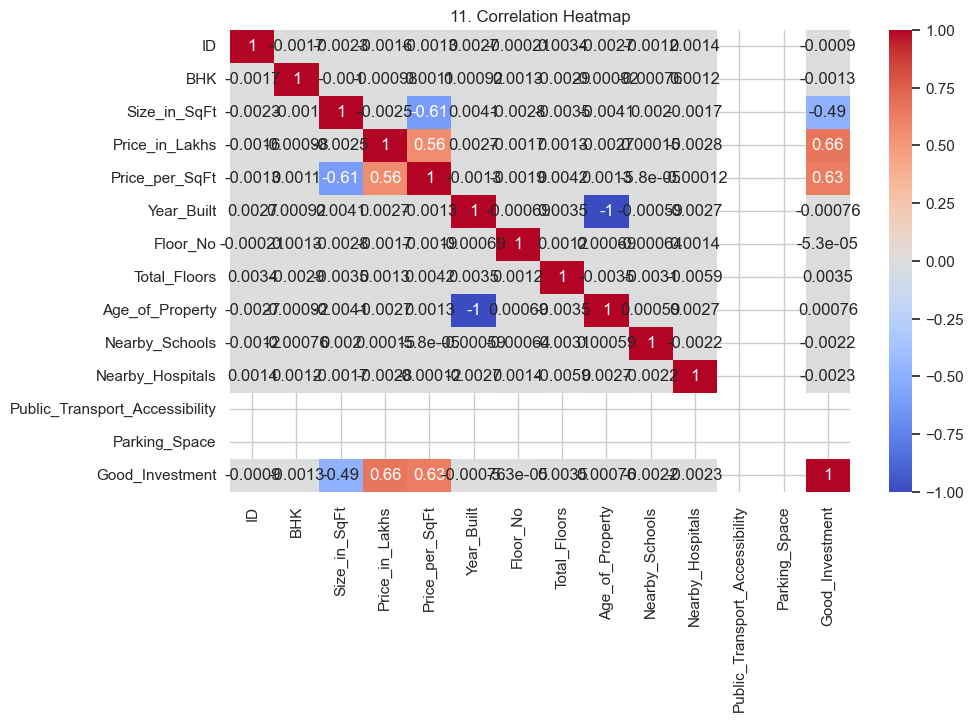

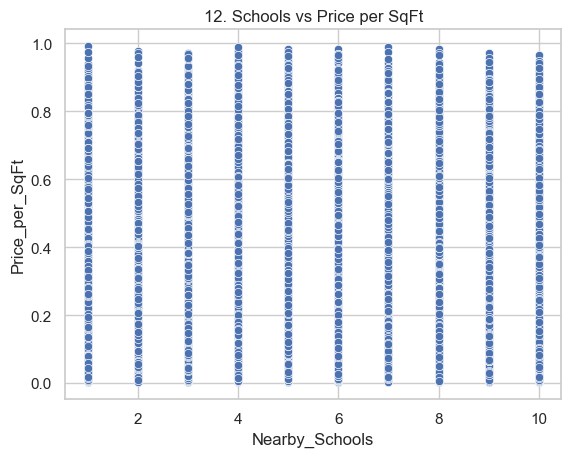

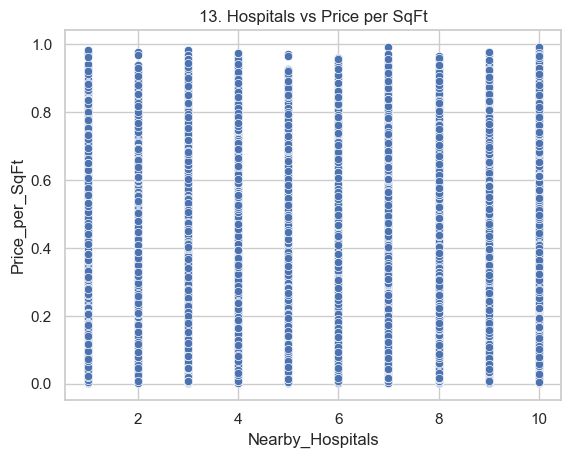

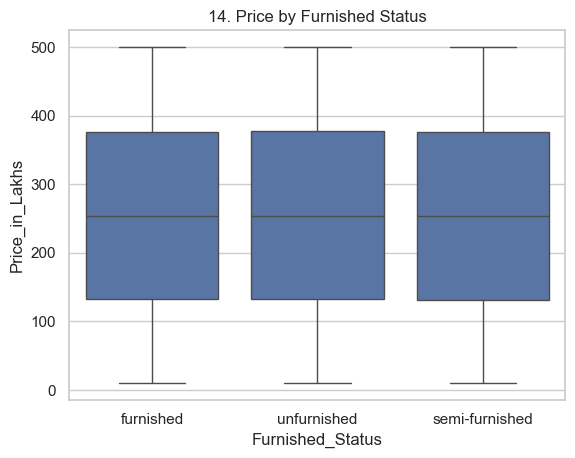

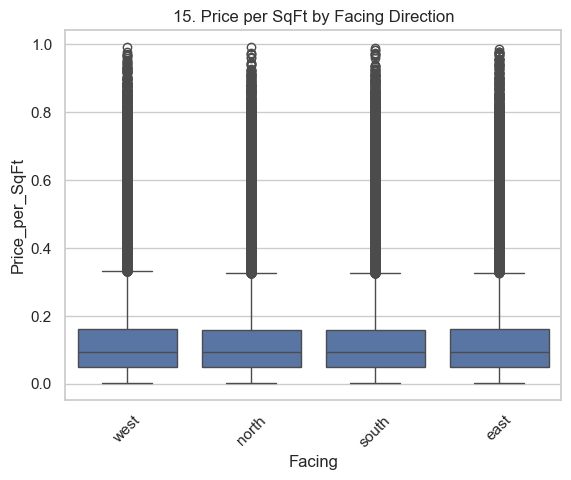


16. Owner Type Count:
 Owner_Type
broker     83479
owner      83268
builder    83253
Name: count, dtype: int64

17. Availability Status:
 Availability_Status
under_construction    125035
ready_to_move         124965
Name: count, dtype: int64


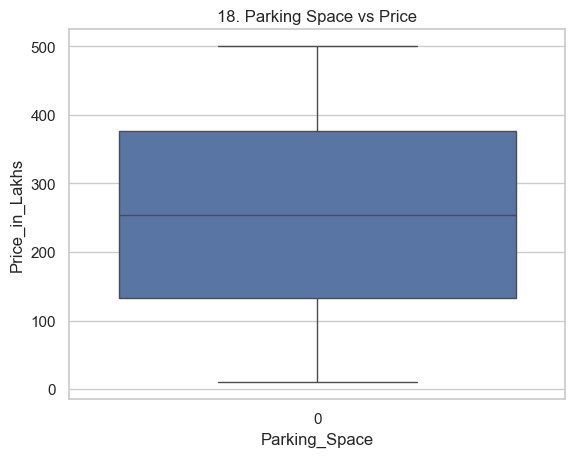

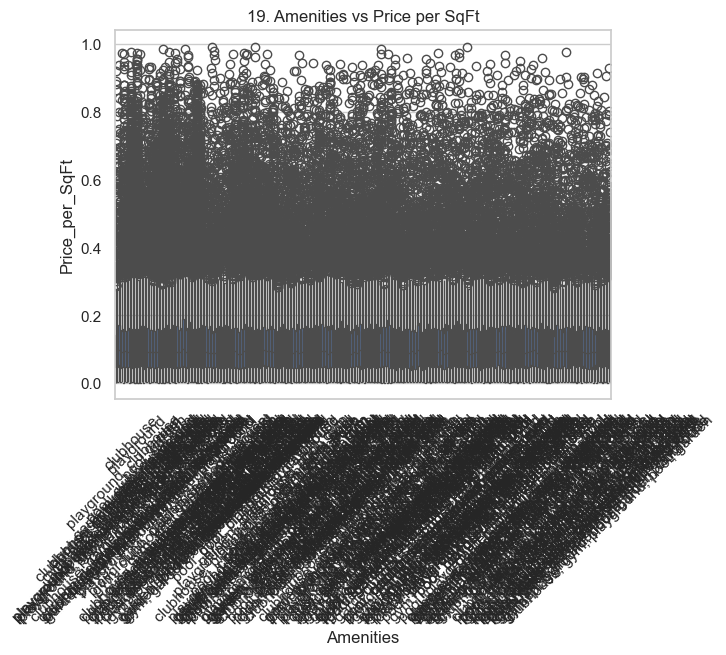

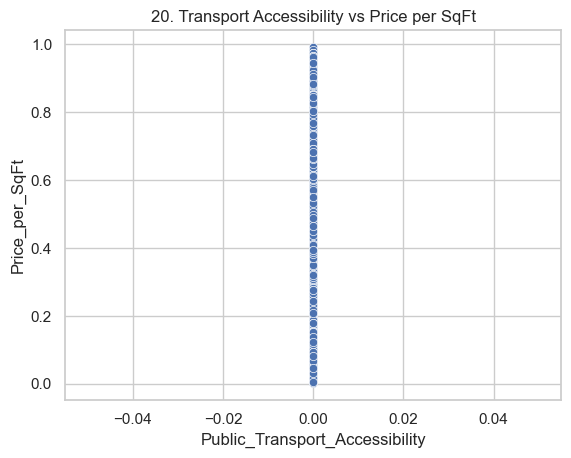


EDA Completed Successfully


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

   
# LOAD CLEANED DATA
   
df = pd.read_csv("cleaned_real_estate_data.csv")

print("Data Loaded:", df.shape)

sns.set(style="whitegrid")

   
# 1–5: PRICE & SIZE ANALYSIS
   

# 1. Price distribution
plt.figure()
sns.histplot(df['Price_in_Lakhs'], kde=True)
plt.title("1. Distribution of Property Prices")
plt.show()

# 2. Size distribution
plt.figure()
sns.histplot(df['Size_in_SqFt'], kde=True)
plt.title("2. Distribution of Property Sizes")
plt.show()

# 3. Price per sqft by property type
plt.figure()
sns.boxplot(x='Property_Type', y='Price_per_SqFt', data=df)
plt.xticks(rotation=45)
plt.title("3. Price per SqFt by Property Type")
plt.show()

# 4. Size vs Price relationship
plt.figure()
sns.scatterplot(x='Size_in_SqFt', y='Price_in_Lakhs', data=df)
plt.title("4. Size vs Price")
plt.show()

# 5. Outliers check
plt.figure()
sns.boxplot(y=df['Price_per_SqFt'])
plt.title("5. Outliers in Price per SqFt")
plt.show()


   
# 6–10: LOCATION-BASED ANALYSIS
   

# 6. Avg price per sqft by state
state_price = df.groupby('State')['Price_per_SqFt'].mean().sort_values(ascending=False)
print("\n6. Avg Price per SqFt by State:\n", state_price)

# 7. Avg property price by city
city_price = df.groupby('City')['Price_in_Lakhs'].mean().sort_values(ascending=False)
print("\n7. Avg Property Price by City:\n", city_price)

# 8. Median age by locality
locality_age = df.groupby('Locality')['Age_of_Property'].median()
print("\n8. Median Age by Locality:\n", locality_age)

# 9. BHK distribution across cities
plt.figure()
sns.countplot(x='BHK', hue='City', data=df)
plt.title("9. BHK Distribution Across Cities")
plt.show()

# 10. Top 5 expensive localities
top_localities = df.groupby('Locality')['Price_in_Lakhs'].mean().nlargest(5)
print("\n10. Top 5 Expensive Localities:\n", top_localities)


   
# 11–15: FEATURE RELATIONSHIP
   

# 11. Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("11. Correlation Heatmap")
plt.show()

# 12. Schools vs price per sqft
plt.figure()
sns.scatterplot(x='Nearby_Schools', y='Price_per_SqFt', data=df)
plt.title("12. Schools vs Price per SqFt")
plt.show()

# 13. Hospitals vs price per sqft
plt.figure()
sns.scatterplot(x='Nearby_Hospitals', y='Price_per_SqFt', data=df)
plt.title("13. Hospitals vs Price per SqFt")
plt.show()

# 14. Price by furnished status
plt.figure()
sns.boxplot(x='Furnished_Status', y='Price_in_Lakhs', data=df)
plt.title("14. Price by Furnished Status")
plt.show()

# 15. Price per sqft by facing
plt.figure()
sns.boxplot(x='Facing', y='Price_per_SqFt', data=df)
plt.xticks(rotation=45)
plt.title("15. Price per SqFt by Facing Direction")
plt.show()


   
# 16–20: INVESTMENT & AMENITIES
   

# 16. Owner type count
owner_count = df['Owner_Type'].value_counts()
print("\n16. Owner Type Count:\n", owner_count)

# 17. Availability status count
availability_count = df['Availability_Status'].value_counts()
print("\n17. Availability Status:\n", availability_count)

# 18. Parking vs price
plt.figure()
sns.boxplot(x='Parking_Space', y='Price_in_Lakhs', data=df)
plt.title("18. Parking Space vs Price")
plt.show()

# 19. Amenities vs price per sqft
plt.figure()
sns.boxplot(x='Amenities', y='Price_per_SqFt', data=df)
plt.xticks(rotation=45)
plt.title("19. Amenities vs Price per SqFt")
plt.show()

# 20. Transport accessibility vs price
plt.figure()
sns.scatterplot(x='Public_Transport_Accessibility', y='Price_per_SqFt', data=df)
plt.title("20. Transport Accessibility vs Price per SqFt")
plt.show()

print("\nEDA Completed Successfully")